# Time Series Components

A time series records the same variable for the same unit over ordered time periods, usually at equal intervals. The order matters: changing the row order changes the scientific meaning.

The lecture separates a series into four ideas:

- Trend: long-run upward or downward movement.
- Seasonal variation: a pattern that repeats within a calendar year, quarter cycle, month cycle, week cycle, or similar fixed period.
- Cycle: broader up-and-down movement around the trend, often longer than a single seasonal cycle.
- Irregular fluctuation: remaining movement that does not follow a regular pattern.

The first modeling rule is simple: plot the series before fitting a model.

In [1]:
from lite_setup import ensure_packages
await ensure_packages()

Running outside JupyterLite; assuming packages are already installed.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson
from checks import check_columns, check_no_missing

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
cod = pd.read_csv(Path('data/cod_catch.csv'))
calc = pd.read_csv(Path('data/calculator_sales.csv'))
loan = pd.read_csv(Path('data/loan_requests.csv'))
print(check_columns(cod, ['Time', 'Month', 'Catch']))
print(check_columns(calc, ['Time', 'Month', 'Sales']))
print(check_columns(loan, ['Time', 'Month', 'LoanRequests']))

Ready: found Time, Month, Catch
Ready: found Time, Month, Sales
Ready: found Time, Month, LoanRequests


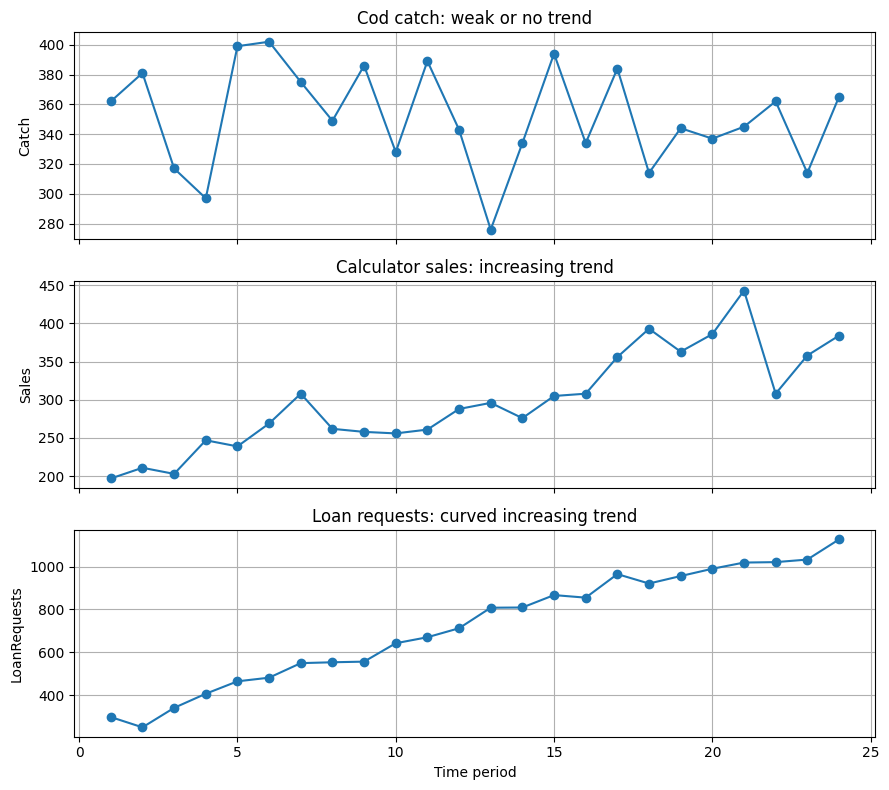

In [3]:
examples = [
    (cod, 'Catch', 'Cod catch: weak or no trend'),
    (calc, 'Sales', 'Calculator sales: increasing trend'),
    (loan, 'LoanRequests', 'Loan requests: curved increasing trend'),
]
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for ax, (df, y, title) in zip(axes, examples):
    ax.plot(df['Time'], df[y], marker='o')
    ax.set_ylabel(y)
    ax.set_title(title)
axes[-1].set_xlabel('Time period')
plt.tight_layout()

Interpretation prompts:

- Cod catch fluctuates around a roughly stable level, so a no-trend mean model is a possible first baseline.
- Calculator sales generally increase, so a linear trend is a possible first model.
- Loan requests increase with curvature, so a quadratic trend may be more appropriate than a straight line.

These are visual hypotheses. The next notebook turns them into regression models.

## Seasonal Swing and Level

Two lecture terms are useful when judging whether seasonality is additive or multiplicative:

- Seasonal swing is the vertical distance between seasonal peaks and troughs within a repeating cycle.
- Level is the typical height of the series during a span of time.

If the seasonal swing stays roughly the same as the level changes, additive seasonality is a reasonable first description. If the seasonal swing grows as the level grows, multiplicative seasonality is more plausible and a transformation may help.

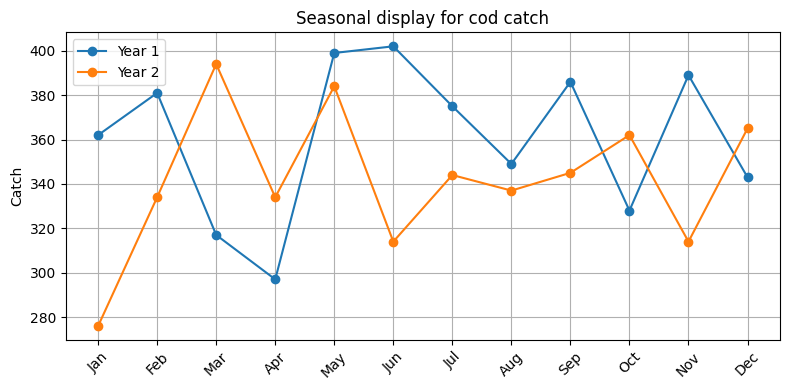

In [4]:
def seasonal_plot(df, value_col, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    for year, group in df.groupby('Year'):
        ax.plot(group['MonthNumber'], group[value_col], marker='o', label=f'Year {year}')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months, rotation=45)
    ax.set_ylabel(value_col)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal_plot(cod, 'Catch', 'Seasonal display for cod catch')

A seasonal display puts the same season from different years into comparable positions. For monthly data, compare January to January, February to February, and so on. For quarterly data, compare Q1 to Q1, Q2 to Q2, etc.

Transfer question: when you receive a new time series, what would you plot before fitting any regression model?